# House Price Prediction

## Day1: Dataset understanding

## 1.Load csv

In [1]:
import pandas as pd 
import numpy as np
df=pd.read_csv("../data/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 2. Shape of Dataset and its datatypes

In [2]:
df.shape

(2930, 82)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [4]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [5]:
df["SalePrice"].head()

0    215000
1    105000
2    172000
3    244000
4    189900
Name: SalePrice, dtype: int64

## 3. Target Variable Analysis

The target variable for this regression problem is `SalePrice`.

Unlike classification, where the target represents discrete classes, `SalePrice`
is a continuous numerical variable.

The target has a mean of approximately USD 180,796  and a median of USD 160,000.
Since the mean is higher than the median, the target distribution is likely
positively skewed.

The histogram confirms that most houses are concentrated in the lower-to-middle
price range, while a smaller number of expensive houses create a long right tail.

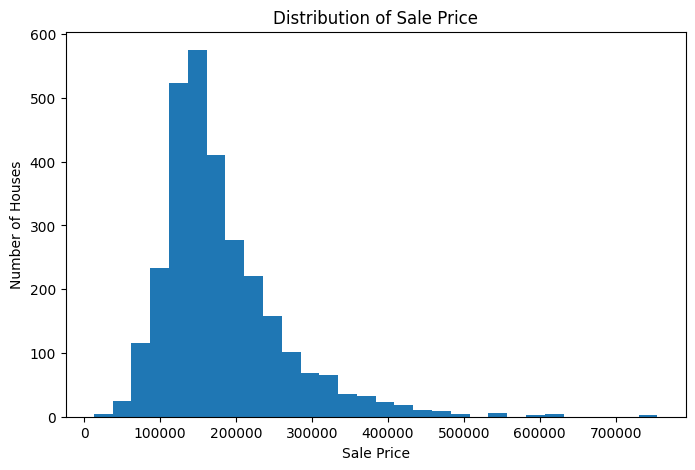

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["SalePrice"], bins=30)

plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of Sale Price")

plt.show()

## 4. Feature Overview

The dataset contains both numerical and categorical features.

Numerical features represent measurable quantities such as area, number of rooms,
year built, and garage capacity.

Categorical features represent properties such as neighborhood, house style,
foundation type, and heating system.

Understanding these feature types is important because they will require different
preprocessing techniques before being used by machine learning models.

In [7]:
df.dtypes.value_counts()

object     43
int64      28
float64    11
Name: count, dtype: int64

In [8]:
df["Overall Qual"].describe()

count    2930.000000
mean        6.094881
std         1.411026
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: Overall Qual, dtype: float64

In [9]:
df["Gr Liv Area"].describe()

count    2930.000000
mean     1499.690444
std       505.508887
min       334.000000
25%      1126.000000
50%      1442.000000
75%      1742.750000
max      5642.000000
Name: Gr Liv Area, dtype: float64

### Initial Feature Observations

The dataset contains 43 categorical features and 39 numerical features. Therefore,
categorical encoding will be an important part of the preprocessing stage.

`Overall Qual` ranges from 1 to 10 and represents an ordered measure of overall
house quality. Its relationship with `SalePrice` will be investigated during EDA.

`Gr Liv Area` has a mean of approximately 1,500 square feet and a maximum of
5,642 square feet. The large difference between its typical values and maximum
suggests that some houses have unusually large living areas, which should be
investigated during EDA before deciding how to handle them.

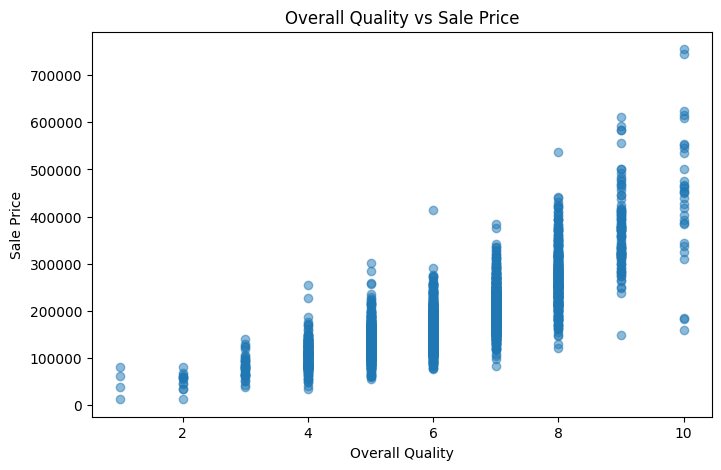

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Overall Qual"], df["SalePrice"], alpha=0.5)

plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Overall Quality vs Sale Price")

plt.show()

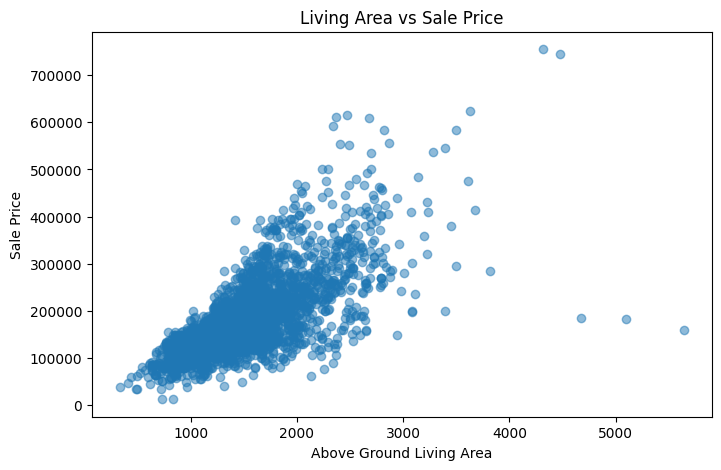

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Gr Liv Area"], df["SalePrice"], alpha=0.5)

plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")
plt.title("Living Area vs Sale Price")

plt.show()

### Overall Quality and Sale Price

The scatter plot shows a positive relationship between `Overall Qual` and
`SalePrice`. In general, houses with higher overall quality tend to have higher
sale prices.

However, there is considerable variation in price among houses with the same
quality rating, indicating that other features also contribute to house prices.

### Living Area and Sale Price

The scatter plot shows a positive relationship between `Gr Liv Area` and
`SalePrice`. In general, houses with larger above-ground living areas tend to
have higher sale prices.

However, the relationship is not perfectly linear, and there is considerable
variation in sale prices for houses with similar living areas.

A few observations have unusually large living areas but relatively low sale
prices. These observations should be investigated further during EDA before
deciding whether they require special treatment.

## 5. Correlation with Sale Price

Correlation measures the strength and direction of a linear relationship between
two numerical variables.

A positive correlation indicates that higher values of one variable tend to be
associated with higher values of the other variable, while a negative correlation
indicates the opposite.

Correlation does not imply causation.

In [12]:
numeric_corr = df.select_dtypes(include=["int64", "float64"]).corr()

saleprice_corr = numeric_corr["SalePrice"].sort_values(ascending=False)

saleprice_corr.head(10)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Name: SalePrice, dtype: float64

In [13]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

## 6. Missing Value Overview

The dataset contains missing values in several features. Some features have a
very high number of missing values, such as `Pool QC`, `Misc Feature`, `Alley`,
`Fence`, and `Fireplace Qu`.

For these features, missing values may indicate that the corresponding feature
does not exist for the house rather than representing missing information.

Other features, such as `Lot Frontage`, `Mas Vnr Area`, and several garage and
basement-related features, contain fewer missing values and will require further
investigation during preprocessing.

Therefore, missing values will not be removed or replaced blindly. Their meaning
will be considered when deciding the appropriate preprocessing strategy.